# Project



#  Deep Learning for Gemological Analysis: From Morphology to Radiometric Feature Extraction

##  Abstract and Theoretical Context
This project explores the application of **Computer Vision** and **Deep Learning** methodologies within the field of gemology. The investigation relies on a custom **Convolutional Neural Network (CNN)** built from scratch to automatically classify polished diamonds from single-view digital acquisitions.
While the initial phase of the study establishes a baseline by classifying macroscopic geometric morphology (e.g., *Round, Oval, Emerald*), the core research shifts towards a significantly more complex challenge: the extraction of fine-grained radiometric and structural features to classify diamond **Color** and a Cartesian combination of **Color × Symmetry**.

##  Research Objectives and Phased Approach
To rigorously evaluate the model's capacity and generalization capabilities, the project is structured into three progressive complexity phases:
* **Phase 1 (Baseline - Shape Classification):** Establishing a baseline on geometric shape. Given that CNNs act as powerful edge detectors, this task proves relatively trivial, rapidly reaching near-perfect accuracy.
* **Phase 2 (Color Classification):** Shifting the target to the diamond's color grade (11 curated classes from D to N), forcing the network to ignore geometric boundaries and focus on subtle pixel-intensity variations.
* **Phase 3 (Combined Cartesian Target):** The ultimate challenge involves predicting a combined target of **Color × Symmetry** (restricted to *Excellent* and *Very Good* grades). This generates a highly balanced, 22-class problem that represents a realistic and articulate deep learning task.

##  Methodology and Engineering Pipeline
The project pipeline strictly adheres to standardized **PyTorch** deep learning engineering frameworks, integrating modern architectural paradigms (e.g., AlexNet-inspired design):

* **Hardware Acceleration and Data Ingestion:** Initialization of GPU-accelerated tensor computation (`CUDA`) alongside localized data caching to eliminate I/O throughput bottlenecks during batch generation.
* **Pre-processing and Data Curation:** Rigorous data sanitization (filtering outliers and rare classes to ensure homogeneous distributions), spatial rescaling ($224 \times 224$), and an 80/20 stratified train/validation split.
* **Architectural Design:** Implementation of a custom AlexNet-inspired convolutional backbone from scratch (without pre-trained weights). The architecture integrates `BatchNorm2d`, `ReLU` activations, and `Dropout` mechanisms to mitigate vanishing gradients and prevent overfitting.
* **Optimization and Training Loop:** Iterative forward-backward passes utilizing `CrossEntropyLoss` as the objective function to guide parameter updates via Stochastic Gradient Descent.
* **Performance Assessment:** Comprehensive evaluation utilizing training/validation loss curves and per-class performance metrics to thoroughly evaluate inter-class discriminability across the three phases.


# 1. The dataset

## 1.1 Data Ingestion and I/O Optimization

Before initiating the dataset manipulation and model training phases, it is imperative to establish an efficient data pipeline. Fetching thousands of images directly from a mounted cloud drive (Google Drive) during training typically introduces severe Input/Output (I/O) latency, which bottlenecks the GPU.

###  Engineering Choice: Local Disk Caching
To optimize the training pipeline, we integrated a script that programmatically copies the entire image dataset from the remote Google Drive virtual file system to the local NVMe storage of the Colab instance (`/content/diamond_images`). This architectural choice prevents network-bound I/O bottlenecks and drastically reduces the execution time of each training epoch, ensuring maximum computational throughput.

In [ ]:
# 1. Import necessary libraries for data manipulation, computer vision, and deep learning
import os
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
from PIL import Image
import shutil

# Check if a GPU is available for hardware acceleration, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active computational device: {device}")

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Set project directories (mantenendo lo spazio esatto della cartella su Drive)
base_dir = '/content/drive/MyDrive/Progetto diamanti '
csv_path = os.path.join(base_dir, 'web_scraped/diamond_data.csv')

# Define a local directory path inside the Colab virtual machine environment
local_dir = '/content/diamond_images'
# Define the source directory path in Google Drive where the images are currently located
drive_images_dir = os.path.join(base_dir, 'web_scraped')

if os.path.exists(local_dir):
    print("Rimuovo la copia locale incompleta/precedente...")
    shutil.rmtree(local_dir)

print("Copying images from Drive to local disk to speed up I/O operations...")
shutil.copytree(drive_images_dir, local_dir, ignore=shutil.ignore_patterns('*.gsheet'))
print(" Copy completed!")

# 4. Load dataset metadata
df = pd.read_csv(csv_path)
df = df.dropna(subset=['path_to_img', 'shape']).reset_index(drop=True)

print(f"\n 'diamond_data.csv' successfully loaded: {len(df)} valid samples found!\n")
display(df.head(3))

# Define a list of specific diamond stock numbers that are known to be corrupted or invalid
bad_stock_numbers = ['220188-630', '220376-42']
df = df[~df['stock_number'].astype(str).isin(bad_stock_numbers)].reset_index(drop=True)

print(f"Data cleaning completed. Valid samples remaining: {len(df)}")

# 5. Inspect target class distribution
print("\n---  Diamond Shape Classes ---")
print(df['shape'].value_counts())

Active computational device: cuda


In [ ]:
import os

# Controlliamo se la cartella esiste prima di copiarla
if os.path.exists(drive_images_dir):
    print("✅ Cartella web_scraped trovata correttamente!")
else:
    print("❌ Attenzione: La cartella non è qui. Ecco cosa c'è dentro Progetto diamanti:")
    print(os.listdir(base_dir))

NameError: name 'drive_images_dir' is not defined

## 1.2 Exploratory Data Analysis (EDA) & Qualitative Inspection

Before designing and training the Convolutional Neural Network, it is crucial to perform a qualitative inspection of the dataset. This step, commonly referred to as **Exploratory Data Analysis (EDA)**, serves as a visual sanity check to ensure the integrity of the data ingestion pipeline and to understand the morphological variance across different target classes.

### 🔍 Cell Objectives and Methodology:
* **Random Sampling:** We dynamically extract the unique diamond shape categories from the dataset and randomly sample one representative image for each class.
* **I/O Optimization:** The images are loaded directly from the localized Colab cache (`local_dir`) rather than the remote Google Drive, ensuring zero-latency rendering and demonstrating efficient resource management.
* **Visual Verification:** By displaying these samples in a Matplotlib grid, we can visually confirm that the images are correctly formatted (standard RGB), uncorrupted, and accurately labeled before they are passed into the deep learning pipeline.

## 2. Custom Dataset Definition and Pre-processing Pipeline

To efficiently feed data into the neural network, we must bridge the gap between our raw files (images and CSV metadata) and PyTorch's tensor-based computation engine. This is achieved by subclassing the abstract `torch.utils.data.Dataset` class.

### Architectural Choices:
* **Lazy Loading:** Instead of loading all images into RAM simultaneously (which would cause memory overflow), the `__getitem__` method loads images dynamically from the local disk one by one as requested by the batch generator.
* **Deterministic Label Encoding:** Neural networks cannot process text. We dynamically build a deterministic dictionary (`shape_map`) that maps string categorical labels (e.g., "Round", "Oval") to discrete integer identifiers ($0, 1, ..., N-1$).
* **Spatial Normalization:** The `transforms.Compose` pipeline enforces a strict spatial resolution of $64 \times 64$ pixels. This uniformity is mathematically necessary to concatenate individual image tensors into multi-dimensional mini-batches. Furthermore, `ToTensor()` scales pixel intensities into the $[0.0, 1.0]$ continuous domain, stabilizing the gradients during backpropagation.

## 3. Stratified Data Splitting and Batch Generation

In this phase, we partition our dataset into disjoint subsets for training and evaluation, and establish the batch-generation infrastructure required for stochastic gradient descent.

### Methodological Choices:
* **Stratified Sampling:** We utilize scikit-learn's `train_test_split` with the `stratify` parameter. In highly imbalanced datasets, standard random sampling can result in minority classes being absent from the validation set. Stratification statistically guarantees that the underlying distribution of morphological classes is identical across both the $80\%$ Training and $20\%$ Validation subsets.
* **Path Alignment:** Since the data ingestion pipeline was optimized to utilize the local virtual machine's cache, the relative file paths within the DataFrame are dynamically updated to point to the correct local subdirectories.
* **Mini-Batch DataLoaders:** The `torch.utils.data.DataLoader` wraps our custom dataset to provide asynchronous iterable access. We selected a `batch_size` of 128 to maximize GPU memory utilization and stabilize the gradient approximations. Furthermore, `shuffle=True` is exclusively applied to the training set to prevent the network from memorizing sequence-based heuristics.

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# 1. Define the Data Preprocessing Pipeline
# - Resize: Enforces a uniform spatial resolution (64x64) necessary for batch tensor stacking.
# - ToTensor: Converts the PIL Image into a 32-bit floating-point PyTorch tensor
#   and normalizes the pixel intensity values from [0, 255] to the [0.0, 1.0] range.
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# 2. Custom Dataset Implementation
class Diamond(Dataset):
    """
    Custom PyTorch Dataset class designed to lazy-load diamond images and their
    corresponding morphological target labels from the local filesystem.
    """
    def __init__(self, dataframe, base_dir, transform=None):
        # Reset index to ensure sequential access without index gaps
        self.data = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform

        # Label Encoding: Dynamically build a mapping dictionary from
        # categorical string labels to discrete integer class IDs (0, 1, 2, ... N-1).
        # This is mathematically required by the CrossEntropyLoss function.
        self.shapes = sorted(self.data['shape'].unique())
        self.shape_map = {name: i for i, name in enumerate(self.shapes)}

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        Crucial for the DataLoader to determine epoch boundaries.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Fetches the sample at the specified index.
        Implements a lazy-loading paradigm to minimize RAM consumption.
        """
        # Construct the absolute file path by joining the local base directory
        # with the relative path extracted from the DataFrame
        rel_path = str(self.data.iloc[idx]['path_to_img'])
        img_path = os.path.join(self.base_dir, rel_path)

        # Load the image from disk and strictly convert it to the RGB color space
        # (dropping potential alpha channels that would break tensor dimensions)
        image = Image.open(img_path).convert('RGB')

        # Apply the defined torchvision transformations
        if self.transform:
            image = self.transform(image)

        # Extract the categorical string label and map it to its corresponding integer ID.
        # It is cast to a torch.long tensor, which is the required datatype for classification targets.
        label_shape = torch.tensor(self.shape_map[self.data.iloc[idx]['shape']], dtype=torch.long)

        return image, label_shape

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# 1. Dataset Curation
# Exclude the "marquise" class (if deemed an outlier or out of the project scope) and reset the index
dataset = df[df['shape'] != "marquise"].reset_index(drop=True)
print(f"Samples remaining after excluding 'marquise': {len(dataset)}")

# 2. Stratified Train-Validation Split (80/20)
# 'stratify=dataset["shape"]' strictly enforces that the original class distribution
# is preserved across both the training and validation subsets.
train_df, test_df = train_test_split(dataset, test_size=0.2, stratify=dataset["shape"], random_state=42)

# 3. Path Correction for Local Cache
# Explicitly copy the dataframes to prevent Pandas' 'SettingWithCopyWarning'
train_df = train_df.copy()
test_df = test_df.copy()

# Strip the 'web_scraped/' prefix from the strings because our 'local_dir'
# already maps directly to the contents of that folder.
train_df['path_to_img'] = train_df['path_to_img'].str.replace('web_scraped/', '', regex=False)
test_df['path_to_img'] = test_df['path_to_img'].str.replace('web_scraped/', '', regex=False)

# 4. Instantiate the Custom Datasets
# Bind the cleaned dataframes to our custom Dataset class, pointing to the fast local storage
train_dataset = Diamond(train_df, local_dir, transform=data_transforms)
test_dataset = Diamond(test_df, local_dir, transform=data_transforms)

# 5. Configure DataLoaders for Batch Generation
# A batch size of 128 optimally utilizes the T4 GPU's VRAM for parallel matrix multiplication
batch_size = 128

# Instantiate PyTorch DataLoaders.
# shuffle=True for training prevents the model from learning sequential biases.
# num_workers=2 enables multiprocessing to prepare batches in the background.
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Samples remaining after excluding 'marquise': 48298


## 4. Convolutional Neural Network (CNN) Architecture

In this section, we define the topology of our deep learning model. Rather than utilizing a pre-trained, heavy architecture (such as ResNet or VGG), we implemented a custom, lightweight Convolutional Neural Network from scratch. This tailored approach is computationally efficient and perfectly suited for extracting geometric features from $64 \times 64$ images.

###  Architectural Components:
* **Convolutional Backbone (Blocks 1 & 2):** The feature extractor consists of two sequential blocks. Each block pairs a $3 \times 3$ Convolutional layer (which detects spatial hierarchies like edges and corners) with a ReLU activation function and a $2 \times 2$ Max Pooling layer. The pooling layers systematically compress the spatial dimensions, providing translation invariance.
* **Dimensionality and Flattening Transition:** After two pooling operations, the original $64 \times 64$ spatial resolution is reduced to $16 \times 16$. Given that the final convolutional layer outputs 64 distinct feature maps, the total number of flattened parameters fed to the dense layers is calculated strictly as: $64 \times 16 \times 16 = 16384$.
* **Classification Head:** The fully connected component condenses the $16384$ extracted features into a $128$-dimensional latent representation, before applying a final linear projection to output the raw logits for the $7$ remaining diamond shape classes.

In [ ]:
import torch
import torch.nn as nn

# Instantiate the Convolutional Neural Network using the Sequential container
net = nn.Sequential(

    # === CONVOLUTIONAL BACKBONE: FEATURE EXTRACTION ===

    # --- Block 1: Low-level feature extraction (edges, simple geometries) ---
    # Input: 3 channels (RGB). Output: 32 feature maps.
    # A 3x3 kernel with padding=1 preserves the original 64x64 spatial resolution.
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    # ReLU activation introduces non-linearity, allowing the network to learn complex patterns
    nn.ReLU(),
    # MaxPooling downsamples the spatial dimensions by a factor of 2 (64x64 -> 32x32),
    # retaining the most prominent features while reducing computational complexity.
    nn.MaxPool2d(kernel_size=2, stride=2),

    # --- Block 2: High-level feature extraction (complex shapes, corners) ---
    # Input: 32 channels. Output: 64 feature maps.
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    # MaxPooling downsamples the spatial dimensions again by a factor of 2 (32x32 -> 16x16).
    nn.MaxPool2d(kernel_size=2, stride=2),

    # === FULLY CONNECTED HEAD: CLASSIFICATION ===

    # The Flatten layer unrolls the 3D tensor into a 1D vector.
    # Tensor dimensions before flattening: 64 (channels) x 16 (height) x 16 (width).
    # 64 * 16 * 16 = 16384 scalar values.
    nn.Flatten(),

    # The first dense layer projects the 16384 extracted features into a smaller,
    # 128-dimensional latent space.
    nn.Linear(16384, 128),
    nn.ReLU(),

    # Output Layer: Maps the 128 hidden activations to the 7 target morphological classes.
    # Note: We output raw logits. The Softmax activation is mathematically embedded
    # inside the PyTorch CrossEntropyLoss function used during training.
    nn.Linear(128, 7)
)

## 5. Model Optimization and Training Loop

In this phase, we initialize the network's parameters and execute the optimization loop to iteratively update the weights. To monitor convergence dynamically, we leverage the `d2l` (Dive into Deep Learning) library, which provides robust utilities for real-time metric visualization.

### ⚙ Training Configuration and Methodology:
* **Xavier Weight Initialization:** We systematically apply Xavier Uniform initialization to all Convolutional and Linear layers. This algorithm balances the variance of activations and gradients across layers, effectively mitigating the vanishing/exploding gradient problem during the early stages of backpropagation.
* **Optimizer & Objective Function:** We employ Stochastic Gradient Descent (SGD) with a learning rate of $0.01$ to minimize the multi-class `CrossEntropyLoss`.
* **Hardware Acceleration:** The training loop dynamically allocates both the model and the batch tensors to the GPU, ensuring maximum computational throughput.
* **Real-time Monitoring:** The `Animator` visualizes the Training Loss, Training Accuracy, and Validation (Test) Accuracy continuously. This allows us to empirically detect the convergence rate and the potential onset of overfitting.


✅ Training Completed:
Final Training Loss: 0.115
Final Training Accuracy: 0.974
Final Validation Accuracy: 0.957


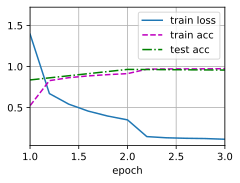

In [ ]:
# Install the 'Dive into Deep Learning' library required for live animated plots
!pip install d2l==1.0.0a1.post0
# Verify GPU availability and memory usage
!nvidia-smi

import torch
from torch import nn
from d2l import torch as d2l

def train(net, train_iter, test_iter, num_epochs, lr, device=d2l.try_gpu()):
    """
    Executes the training loop for the neural network on the specified hardware device.
    """

    # 1. Weight Initialization Strategy
    def init_weights(m):
        # Apply Xavier Uniform initialization strictly to Linear and Convolutional layers
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    # Recursively apply the initialization function to all modules in the network
    net.apply(init_weights)
    print('Training actively on:', device)

    # Move the entire model architecture to the GPU VRAM
    net.to(device)

    # 2. Define Optimizer and Loss Function
    # We use Stochastic Gradient Descent (SGD) to update network parameters
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    # Standard objective function for multi-class classification
    loss = nn.CrossEntropyLoss()

    # 3. Setup Visualization and Tracking
    # Initialize the d2l Animator for real-time plotting of learning curves
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])

    timer, num_batches = d2l.Timer(), len(train_iter)

    # 4. Epoch Loop
    for epoch in range(num_epochs):
        # Accumulator stores: [Sum of Training Loss, Sum of Correct Predictions, Total Samples]
        metric = d2l.Accumulator(3)

        # Set the model to training mode (enables gradient tracking)
        net.train()

        # --- Mini-batch Optimization Loop ---
        for i, (X, y) in enumerate(train_iter):
            timer.start()

            # Reset gradients from the previous iteration
            optimizer.zero_grad()

            # Transfer features (X) and labels (y) to the GPU
            X, y = X.to(device), y.to(device)

            # Forward Pass: compute model predictions
            y_hat = net(X)

            # Compute the multi-class Cross-Entropy Error
            l = loss(y_hat, y)

            # Backward Pass: compute gradients via backpropagation
            l.backward()

            # Optimizer Step: update the model parameters
            optimizer.step()

            # Temporarily disable gradient tracking to compute metrics efficiently
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])

            timer.stop()

            # Calculate running averages for the current epoch
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]

            # Update the animated plot iteratively within the epoch
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))

        # --- Validation Phase ---
        # Evaluate model generalization on the unseen test/validation set
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)

        # Add the final validation accuracy point to the plot for this epoch
        animator.add(epoch + 1, (None, None, test_acc))

    # 5. Final Report
    print(f'\n✅ Training Completed:')
    print(f'Final Training Loss: {train_l:.3f}')
    print(f'Final Training Accuracy: {train_acc:.3f}')
    print(f'Final Validation Accuracy: {test_acc:.3f}')

# --- Execution ---
# Define hyperparameters: Learning Rate and Number of Epochs
lr, num_epochs = 0.01, 3

# Trigger the training process
train(net, train_iter, test_iter, num_epochs, lr, device=d2l.try_gpu())

## 6. Model Training & Validation Execution

We now execute the training process across multiple epochs. For each epoch:
1. The training loop computes gradients and updates network weights via backpropagation.
2. The validation loop evaluates the model on unseen validation data without gradient tracking (`torch.no_grad()`).
3. We log both training and validation losses alongside task-specific accuracies (`shape` and `cut`) to verify that the model is successfully learning both objectives simultaneously.

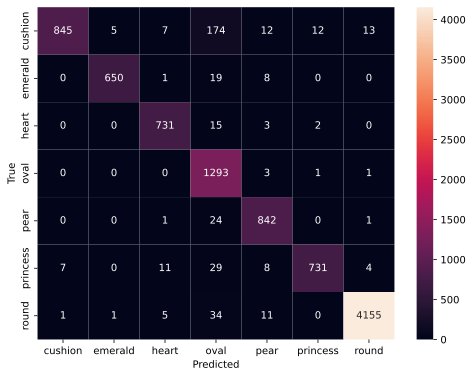

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

net.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_iter:
        X = X.to(device)
        y_hat = net(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_dataset.shapes, yticklabels=test_dataset.shapes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

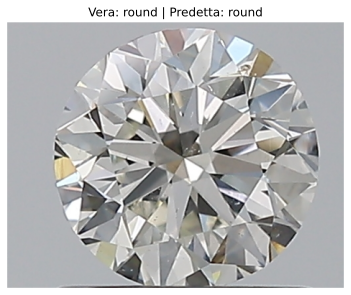

In [ ]:
def predict_random_image():
    net.eval()
    sample_row = test_df.sample(1).iloc[0]
    img_path = os.path.join(local_dir, sample_row['path_to_img'])
    img = Image.open(img_path).convert('RGB')

    img_tensor = data_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = net(img_tensor)
        predicted_idx = torch.argmax(output, dim=1)

    predicted_shape = test_dataset.shapes[predicted_idx.item()]
    true_shape = sample_row['shape']

    plt.imshow(img)
    plt.title(f"Vera: {true_shape} | Predetta: {predicted_shape}")
    plt.axis('off')
    plt.show()

predict_random_image()

🔄 Valutazione in corso sull'intero Validation Set...

💎 CLASSIFICAZIONE FORMA (SHAPE) - REPORT
              precision    recall  f1-score   support

     cushion       0.99      0.79      0.88      1068
     emerald       0.99      0.96      0.97       678
       heart       0.97      0.97      0.97       751
        oval       0.81      1.00      0.90      1298
        pear       0.95      0.97      0.96       868
    princess       0.98      0.93      0.95       790
       round       1.00      0.99      0.99      4207

    accuracy                           0.96      9660
   macro avg       0.96      0.94      0.95      9660
weighted avg       0.96      0.96      0.96      9660



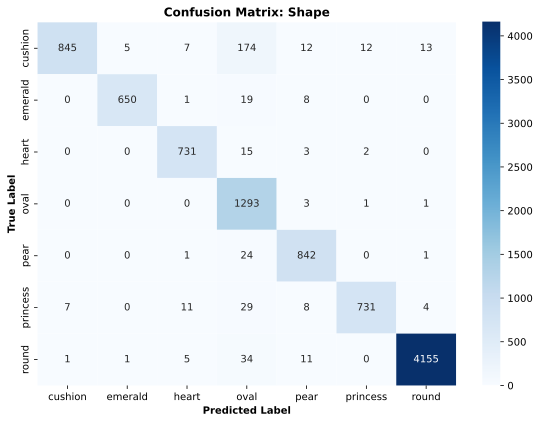

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

net.eval()

# Liste per accumulare tutte le previsioni e le etichette reali per la forma
all_preds_shape, all_true_shape = [], []

print("🔄 Valutazione in corso sull'intero Validation Set...")

with torch.no_grad():
    # Usiamo 'test_iter' che è il loader per il validation set
    # e prevediamo solo 'labels_shape' dato che il dataset è configurato per un singolo task
    for images, labels_shape in test_iter:
        images = images.to(device)
        # Il modello restituisce un singolo output per la forma
        out_shape = net(images)

        _, preds_shape = torch.max(out_shape, 1)

        all_preds_shape.extend(preds_shape.cpu().numpy())
        all_true_shape.extend(labels_shape.numpy())

# Assicuriamoci di avere i nomi delle classi dal dataset di test
# L'oggetto test_dataset ha un attributo 'shapes' per le classi della forma
shape_classes = list(test_dataset.shapes)

# --- REPORT TESTUALE ---
print("\n" + "="*60)
print("💎 CLASSIFICAZIONE FORMA (SHAPE) - REPORT")
print("="*60)
print(classification_report(all_true_shape, all_preds_shape, target_names=shape_classes))

# --- MATRICE DI CONFUSIONE (GRAFICO) ---
plt.figure(figsize=(8, 6))
# Matrice per la Forma
cm_shape = confusion_matrix(all_true_shape, all_preds_shape)
sns.heatmap(cm_shape, annot=True, fmt='d', cmap='Blues',
            xticklabels=shape_classes, yticklabels=shape_classes)
plt.title('Confusion Matrix: Shape', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import torch
from google.colab import files

# 1. Definisci il nome del file di salvataggio
model_save_path = 'diamond_multitask_model.pth'

# 2. Salva i pesi (state_dict) del modello
torch.save(net.state_dict(), model_save_path)
print(f"✅ Pesi del modello salvati con successo in: {model_save_path}")

# 3. Scarica il file automaticamente sul tuo PC
try:
    print("⬇️ Download del file in corso...")
    files.download(model_save_path)
except Exception as e:
    print("⚠️ Impossibile scaricare automaticamente. Trovi il file nella barra laterale a sinistra (cartella file) pronto da scaricare manualmente.")

✅ Pesi del modello salvati con successo in: diamond_multitask_model.pth
⬇️ Download del file in corso...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Colour Classification

In [ ]:
import os
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

# 1. Filter only the main colour classes required for the project (D to N)
main_colours = ['D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N']
dataset_colour = df[df['colour'].isin(main_colours)].reset_index(drop=True)

print(f"Samples after colour cleaning: {len(dataset_colour)}")

# 2. Stratified 80/20 split between training and test sets
train_df_colour, test_df_colour = train_test_split(
    dataset_colour,
    test_size=0.2,
    stratify=dataset_colour['colour'],
    random_state=42
)

# 3. Align paths to utilize local cache
train_df_colour = train_df_colour.copy()
test_df_colour = test_df_colour.copy()
train_df_colour['path_to_img'] = train_df_colour['path_to_img'].str.replace('web_scraped/', '', regex=False)
test_df_colour['path_to_img'] = test_df_colour['path_to_img'].str.replace('web_scraped/', '', regex=False)

print(f"Train samples: {len(train_df_colour)} | Test samples: {len(test_df_colour)}")

NameError: name 'df' is not defined

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Transformations with 96x96 resize for GoogLeNet
data_transforms_colour = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

# 2. Custom Dataset definition
class DiamondColourDataset(Dataset):
    def __init__(self, dataframe, base_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.classes = sorted(self.data['colour'].unique())
        self.class_map = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        rel_path = str(self.data.iloc[idx]['path_to_img'])
        img_path = os.path.join(self.base_dir, rel_path)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.class_map[self.data.iloc[idx]['colour']], dtype=torch.long)
        return image, label

# 3. Instantiate Datasets
train_dataset_colour = DiamondColourDataset(train_df_colour, local_dir, transform=data_transforms_colour)
test_dataset_colour = DiamondColourDataset(test_df_colour, local_dir, transform=data_transforms_colour)

# 4. Create DataLoaders
batch_size = 128
train_iter_colour = DataLoader(train_dataset_colour, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter_colour = DataLoader(test_dataset_colour, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        return torch.cat((p1, p2, p3, p4), dim=1)

# GoogLeNet modules (adapted for 3 input channels for RGB images)
b1 = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b2 = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=1),
    nn.ReLU(),
    nn.Conv2d(64, 192, kernel_size=3, padding=1),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b3 = nn.Sequential(
    Inception(192, 64, (96, 128), (16, 32), 32),
    Inception(256, 128, (128, 192), (32, 96), 64),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b4 = nn.Sequential(
    Inception(480, 192, (96, 208), (16, 48), 64),
    Inception(512, 160, (112, 224), (24, 64), 64),
    Inception(512, 128, (128, 256), (24, 64), 64),
    Inception(512, 112, (144, 288), (32, 64), 64),
    Inception(528, 256, (160, 320), (32, 128), 128),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b5 = nn.Sequential(
    Inception(832, 256, (160, 320), (32, 128), 128),
    Inception(832, 384, (192, 384), (48, 128), 128),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

# Final GoogLeNet model for 11 colour classes
net_colour = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 11))

In [ ]:
from d2l import torch as d2l

# Training hyperparameters
lr, num_epochs = 0.05, 10

# Start training with GoogLeNet
train(net_colour, train_iter_colour, test_iter_colour, num_epochs, lr, device=d2l.try_gpu())

# Save weights to Google Drive
model_save_path = os.path.join(base_dir, 'modello_colour_googlenet.pth')
torch.save(net_colour.state_dict(), model_save_path)
print(f"✅ GoogLeNet colour model successfully saved to: {model_save_path}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

net_colour.eval()
all_preds_colour = []
all_labels_colour = []

with torch.no_grad():
    for X, y in test_iter_colour:
        X = X.to(device)
        y_hat = net_colour(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds_colour.extend(preds.cpu().numpy())
        all_labels_colour.extend(y.numpy())

# Per-class classification report
colour_classes = list(test_dataset_colour.classes)
print("\n" + "="*60)
print("💎 DIAMOND COLOUR CLASSIFICATION - REPORT")
print("="*60)
print(classification_report(all_labels_colour, all_preds_colour, target_names=colour_classes))

# Graphical confusion matrix
cm_colour = confusion_matrix(all_labels_colour, all_preds_colour)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_colour, annot=True, fmt='d', cmap='Blues',
            xticklabels=colour_classes, yticklabels=colour_classes)
plt.title('Confusion Matrix: Colour (GoogLeNet)', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()